In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
file = '../data/outs/all_time.csv'

try:
    df = pd.read_csv(file, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo '{file}' não encontrado!")

Dados lidos com sucesso!


In [3]:
df.dtypes

nome      object
n          int64
m          int64
c          int64
fila      object
run        int64
l1         int64
l2         int64
llc        int64
cycles     int64
dtype: object

## Tempo de execução por quantidade de vértices

In [4]:
df_run_n = (
    df.groupby(['nome', 'fila'])['run']
      .agg(['mean', 'std', 'var'])
      .reset_index()
)
df_run_n

,nome,fila,mean,std,var
0,BAY,2LVBQ,77.1,0.316228,0.100000
1,BAY,2LVBQDK,80.5,0.527046,0.277778
2,BAY,BINH,103.5,1.840894,3.388889
3,CAL,2LVBQ,483.3,5.437524,29.566667
4,CAL,2LVBQDK,508.8,4.237400,17.955556
5,CAL,BINH,647.1,5.043147,25.433333
6,COL,2LVBQ,118.4,3.025815,9.155556
7,COL,2LVBQDK,115.1,2.685351,7.211111
8,COL,BINH,149.6,9.070097,82.266667
9,FLA,2LVBQ,310.2,18.292682,334.622222


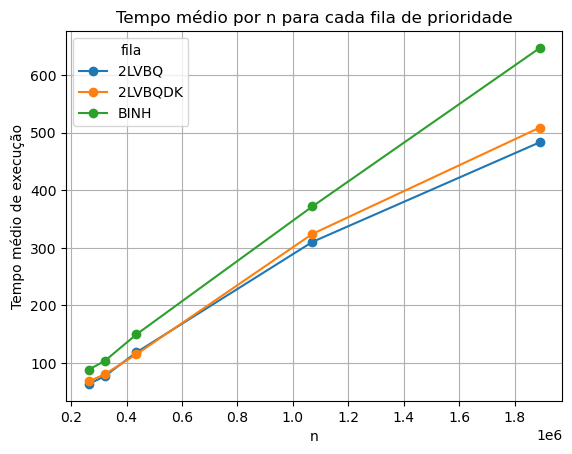

In [5]:
pivot = df.groupby(['n','fila'])['run'].mean().unstack()

pivot.plot(marker='o')
plt.xlabel('n')
plt.ylabel('Tempo médio de execução')
plt.title('Tempo médio por n para cada fila de prioridade')
plt.grid(True)
plt.savefig('run_n.png', dpi=300, bbox_inches='tight')
plt.show()

## Correlação entre métricas e tempo de execução

In [6]:
df['l1_mr'] = df['l1'] / df['cycles']
df['l2_mr'] = df['l2'] / df['cycles']
df['llc_mr'] = df['llc'] / df['cycles']

In [7]:
df_run_miss = (
    df.groupby(['nome','fila'])[['run','l1','l2','llc','cycles', 'l1_mr', 'l2_mr', 'llc_mr']]
      .mean()
      .reset_index()
)
df_run_miss

,nome,fila,run,l1,l2,llc,cycles,l1_mr,l2_mr,llc_mr
0,BAY,2LVBQ,77.1,3609076.0,1935983.7,162517.2,3.375207e+08,0.010693,0.005736,0.000481
1,BAY,2LVBQDK,80.5,3566453.9,1695786.0,170961.5,3.534374e+08,0.010091,0.004798,0.000484
2,BAY,BINH,103.5,2121863.7,1451775.1,160357.3,4.484087e+08,0.004732,0.003238,0.000357
3,CAL,2LVBQ,483.3,23447056.1,14300797.2,1197202.2,2.083950e+09,0.011252,0.006863,0.000574
4,CAL,2LVBQDK,508.8,25724295.3,13137005.7,1295660.7,2.203879e+09,0.011672,0.005961,0.000588
5,CAL,BINH,647.1,15699833.4,10760744.2,1120915.1,2.776320e+09,0.005655,0.003876,0.000404
6,COL,2LVBQ,118.4,4766031.7,2869205.6,228335.6,5.003756e+08,0.009527,0.005735,0.000456
7,COL,2LVBQDK,115.1,4608690.8,2415103.8,231781.5,4.937457e+08,0.009336,0.004892,0.000469
8,COL,BINH,149.6,2879175.7,2097730.2,234223.4,6.159022e+08,0.004678,0.003409,0.000380
9,FLA,2LVBQ,310.2,12155316.7,6685929.8,551173.8,1.222516e+09,0.009955,0.005478,0.000450
